# 05 — Power and minimum detectable effect

**Purpose.** Establish what this experiment was capable of detecting, which is a
different question from what it happened to detect.

Feature 4 found significant effects on all three outcomes for both arms. It is
tempting to conclude the experiment was well designed. That does not follow: finding
an effect proves the effect was large enough to find, not that the design could have
found effects worth acting on.

The right retrospective question is the **minimum detectable effect** — given the
sample size and the variance actually present, how large would an effect have had to
be for this experiment to find it reliably?

The wrong retrospective question, examined in section 4, is "what was our power to
detect the effect we observed?" That number is circular, and it is one of the most
commonly reported statistics in industry A/B testing.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from src import config
from src.data.load import load_processed
from src.analysis.power import (
    run_power_analysis, power_curve, observed_power,
    required_n_for_mean, required_n_for_proportion,
)

pd.set_option("display.width", 150)
df = load_processed()
power_table = run_power_analysis(df, save=False)
print(f"alpha = {config.ALPHA}, target power = {config.POWER_TARGET:.0%}")

alpha = 0.05, target power = 80%


## 1. What could this experiment detect?

In [2]:
power_table[[
    "treatment_arm", "outcome", "mde_absolute", "mde_relative",
    "observed_effect", "observed_ci_low", "effect_to_mde_ratio",
    "ci_low_to_mde_ratio", "robust",
]].style.format({
    "mde_absolute": "{:.4f}",
    "mde_relative": "{:.1%}",
    "observed_effect": "{:+.4f}",
    "observed_ci_low": "{:+.4f}",
    "effect_to_mde_ratio": "{:.2f}x",
    "ci_low_to_mde_ratio": "{:.2f}x",
}).hide(axis="index")

treatment_arm,outcome,mde_absolute,mde_relative,observed_effect,observed_ci_low,effect_to_mde_ratio,ci_low_to_mde_ratio,robust
Mens E-Mail,visit,0.0085,8.0%,+0.0766,+0.0700,9.00x,8.22x,True
Mens E-Mail,conversion,0.0022,39.1%,+0.0068,+0.0050,3.04x,2.23x,True
Mens E-Mail,spend,0.3145,48.2%,+0.7698,+0.4851,2.45x,1.54x,True
Womens E-Mail,visit,0.0085,8.0%,+0.0452,+0.0389,5.32x,4.57x,True
Womens E-Mail,conversion,0.0022,39.1%,+0.0031,+0.0015,1.39x,0.67x,False
Womens E-Mail,spend,0.3145,48.2%,+0.4244,+0.1690,1.35x,0.54x,False


The **relative MDE** column is the striking one. With 21,306 customers per arm,
this experiment could detect:

- an **8%** relative change in visit rate
- a **39%** relative change in conversion rate
- a **48%** relative change in mean spend

A 39% swing in conversion is not an optimisation, it is a transformation. The
experiment was built to answer "does email do anything at all?", and it answers that
emphatically. It was never capable of answering "is this subject line 5% better than
that one".

Why the three differ so much comes down to the ratio of noise to signal. Visit has a
10.6% base rate and modest variance. Conversion has a 0.57% base rate, so the same
absolute precision represents a much larger relative change. Spend has a standard
deviation of about \$11.58 against a mean of \$0.65 — noise roughly **eighteen times**
the quantity being measured.

In [3]:
control = df[df[config.TREATMENT_COL] == config.CONTROL_ARM]
pd.DataFrame({
    "mean": control[config.OUTCOMES].mean(),
    "std dev": control[config.OUTCOMES].std(ddof=1),
    "noise-to-signal": control[config.OUTCOMES].std(ddof=1) / control[config.OUTCOMES].mean(),
}).style.format({"mean": "{:.4f}", "std dev": "{:.4f}", "noise-to-signal": "{:.1f}x"})

,mean,std dev,noise-to-signal
visit,0.1062,0.3081,2.9x
conversion,0.0057,0.0755,13.2x
spend,0.6528,11.5882,17.8x


## 2. Point estimate versus interval

`effect_to_mde_ratio` compares the observed effect to the threshold. But the observed
effect is a single draw; the confidence interval is the range of true effects the data
supports. The more demanding question is whether the effect clears the threshold even
at the **pessimistic end of its interval**.

That distinction separates the six results into two groups:

In [4]:
for _, row in power_table.iterrows():
    mark = "ROBUST     " if row["robust"] else "NOT ROBUST "
    print(f"{mark} {row['treatment_arm']:<14} {row['outcome']:<11} "
          f"CI low {row['observed_ci_low']:+.4f}  vs  MDE {row['mde_absolute']:.4f}")

ROBUST      Mens E-Mail    visit       CI low +0.0700  vs  MDE 0.0085
ROBUST      Mens E-Mail    conversion  CI low +0.0050  vs  MDE 0.0022
ROBUST      Mens E-Mail    spend       CI low +0.4851  vs  MDE 0.3145
ROBUST      Womens E-Mail  visit       CI low +0.0389  vs  MDE 0.0085
NOT ROBUST  Womens E-Mail  conversion  CI low +0.0015  vs  MDE 0.0022
NOT ROBUST  Womens E-Mail  spend       CI low +0.1690  vs  MDE 0.3145


**Four of six are robust.** For those, even the least favourable effect consistent
with the data would still have been detected by a design this size.

**Two are not: Womens E-Mail on conversion and on spend.** Both clear the threshold on
their point estimate — they are genuinely significant, and Feature 4's p-values stand.
But their intervals reach down below the MDE. If the true Womens spend effect were
\$0.17 rather than the estimated \$0.42 — entirely consistent with the evidence — a
repeat of this experiment would frequently miss it.

This is not a reason to disbelieve the result. It is a reason to be careful about what
follows from it, and specifically about comparing the two campaigns: the gap between
Mens and Womens spend effects rests on the arm that is measured least precisely.

## 3. Power curves

Power as a function of effect size, holding the sample at what was actually used. The
question each curve answers: for an effect of a given size, how often would an
experiment this large detect it?

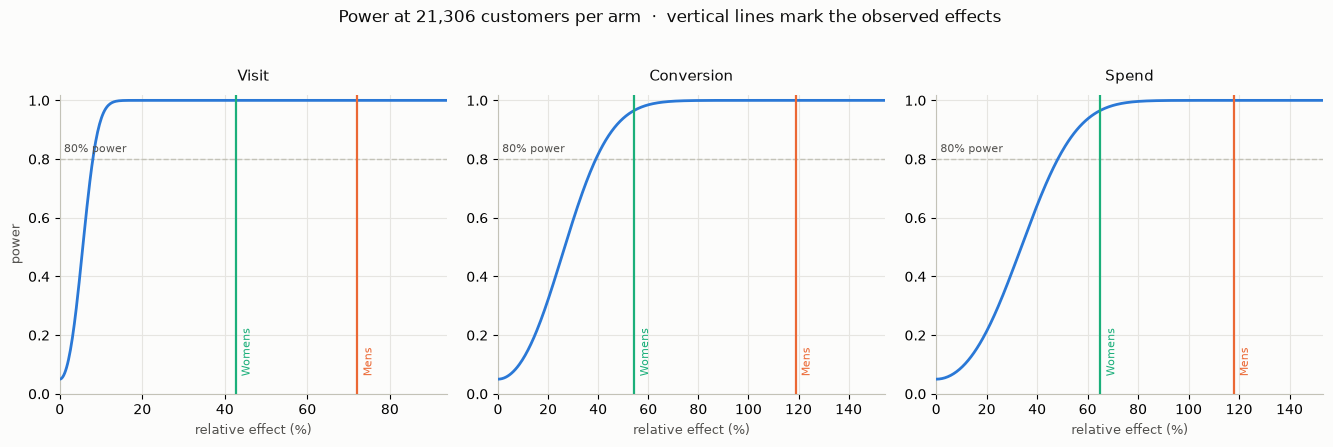

In [5]:
ARM_COLOURS = {"Mens E-Mail": "#eb6834", "Womens E-Mail": "#1baf7a"}
OUTCOME_COLOUR = "#2a78d6"

n_per_arm = int(power_table["n_per_arm"].iloc[0])
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.3))
fig.patch.set_facecolor("#fcfcfb")

for ax, outcome in zip(axes, config.OUTCOMES):
    row = power_table[power_table["outcome"] == outcome].iloc[0]
    ceiling = max(
        row["mde_absolute"] * 3,
        power_table.loc[power_table["outcome"] == outcome, "observed_effect"].max() * 1.3,
    )
    effects = np.linspace(1e-6, ceiling, 400)
    curve = power_curve(
        outcome, row["control_mean"], row["control_sd"], n_per_arm, effects
    )

    ax.plot(curve["relative_effect"] * 100, curve["power"],
            color=OUTCOME_COLOUR, linewidth=2, zorder=3)

    ax.axhline(config.POWER_TARGET, color="#c3c2b7", linewidth=1,
               linestyle="--", zorder=2)
    ax.annotate(f"{config.POWER_TARGET:.0%} power", (0, config.POWER_TARGET),
                xytext=(3, 5), textcoords="offset points",
                fontsize=8, color="#52514e")

    # Where each arm's observed effect actually landed.
    for arm, colour in ARM_COLOURS.items():
        observed = power_table[
            (power_table["outcome"] == outcome)
            & (power_table["treatment_arm"] == arm)
        ].iloc[0]
        relative = observed["observed_effect"] / observed["control_mean"] * 100
        if relative <= curve["relative_effect"].max() * 100:
            ax.axvline(relative, color=colour, linewidth=1.6, zorder=4)
            ax.annotate(arm.replace(" E-Mail", ""), (relative, 0.06),
                        xytext=(4, 0), textcoords="offset points",
                        fontsize=8, color=colour, rotation=90, va="bottom")

    ax.set_facecolor("#fcfcfb")
    ax.set_title(outcome.capitalize(), fontsize=11, color="#0b0b0b", pad=10)
    ax.set_xlabel("relative effect (%)", fontsize=9, color="#52514e")
    ax.set_ylim(0, 1.02)
    ax.set_xlim(0, curve["relative_effect"].max() * 100)
    ax.grid(color="#e6e5e1", linewidth=0.8, zorder=0)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("#c3c2b7")

axes[0].set_ylabel("power", fontsize=9, color="#52514e")
fig.suptitle(
    f"Power at {n_per_arm:,} customers per arm  ·  vertical lines mark the observed effects",
    fontsize=12, color="#0b0b0b", y=1.03,
)
fig.tight_layout()

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "05_power_curves.png", dpi=150, bbox_inches="tight",
            facecolor="#fcfcfb")
plt.show()

The visit curve reaches 80% power at an 8% relative effect and saturates almost
immediately — both observed effects sit far out on the flat part where power is
effectively 100%. The conversion and spend curves rise much more slowly, and the
Womens markers sit noticeably closer to the steep region where power is still
climbing.

## 4. Why "observed power" is not a real diagnostic

A common move after a non-significant result is to report the power to detect the
effect that was observed, and conclude something like "we only had 12% power, so the
absence of evidence is inconclusive."

That statement is circular. Observed power is a **deterministic, monotone function of
the p-value** — it contains no information the p-value did not already carry. A small
p-value always produces high observed power and a large one always produces low
observed power, regardless of sample size or effect size.

The demonstration below computes observed power across a range of results and plots it
directly against the p-value.

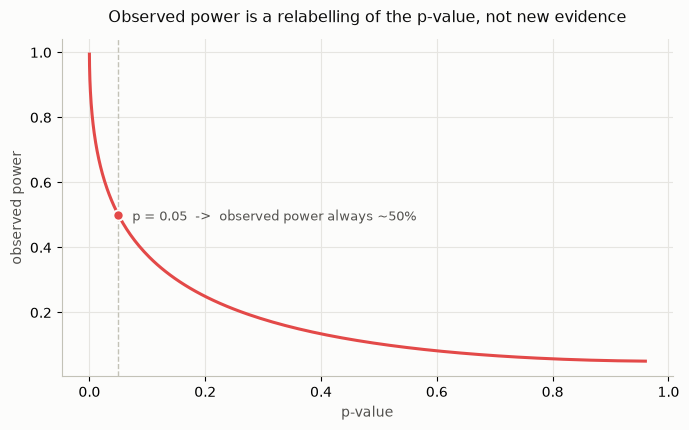

Observed power at a p-value of exactly 0.05, for three different scales:
  SE =   0.01  ->  observed power = 0.5000
  SE =    0.1  ->  observed power = 0.5000
  SE =   10.0  ->  observed power = 0.5000


In [6]:
se = 0.1
effects = np.linspace(0.005, 0.45, 300)
p_values = 2 * stats.norm.sf(np.abs(effects) / se)
powers = np.array([observed_power(e, se, alpha=0.05) for e in effects])

fig, ax = plt.subplots(figsize=(7, 4.4))
fig.patch.set_facecolor("#fcfcfb")
ax.set_facecolor("#fcfcfb")

ax.plot(p_values, powers, color="#e34948", linewidth=2.2, zorder=3)
ax.axvline(0.05, color="#c3c2b7", linewidth=1, linestyle="--", zorder=2)
ax.annotate("p = 0.05  ->  observed power always ~50%",
            (0.05, 0.5), xytext=(10, -4), textcoords="offset points",
            fontsize=9, color="#52514e")
ax.scatter([0.05], [0.5], s=55, color="#e34948", zorder=4,
           edgecolor="#fcfcfb", linewidth=1.4)

ax.set_xlabel("p-value", fontsize=10, color="#52514e")
ax.set_ylabel("observed power", fontsize=10, color="#52514e")
ax.set_title("Observed power is a relabelling of the p-value, not new evidence",
             fontsize=11.5, color="#0b0b0b", pad=12)
ax.grid(color="#e6e5e1", linewidth=0.8, zorder=0)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("#c3c2b7")

fig.tight_layout()
fig.savefig(FIG_DIR / "05_observed_power_fallacy.png", dpi=150,
            bbox_inches="tight", facecolor="#fcfcfb")
plt.show()

print("Observed power at a p-value of exactly 0.05, for three different scales:")
for scale in [0.01, 0.1, 10.0]:
    effect = stats.norm.ppf(0.975) * scale
    print(f"  SE = {scale:>6}  ->  observed power = "
          f"{observed_power(effect, scale, alpha=0.05):.4f}")

One curve, and every result lies on it. A p-value of exactly 0.05 yields ~50%
observed power whether the standard error is 0.01 or 10 — the tell that the quantity
carries no independent information.

The MDE avoids this trap because it depends only on the **design** — sample size,
variance, α, and the power target — and not at all on the result obtained. That is why
it is the number reported above.

## 5. What would it cost to detect a realistic improvement?

The experiment answered "does email work". The more common business question is
incremental: "is this campaign 10% better than that one?" Here is the sample size that
question requires.

In [7]:
rows = []
for outcome in config.OUTCOMES:
    mean = control[outcome].mean()
    sd = control[outcome].std(ddof=1)
    for relative in [0.05, 0.10, 0.20, 0.50]:
        target = relative * mean
        n = (required_n_for_proportion(mean, target)
             if outcome in config.BINARY_OUTCOMES
             else required_n_for_mean(sd, target))
        rows.append({
            "outcome": outcome,
            "relative improvement": relative,
            "absolute effect": target,
            "n per arm": n,
            "vs actual arm size": n / n_per_arm,
        })

pd.DataFrame(rows).style.format({
    "relative improvement": "{:.0%}",
    "absolute effect": "{:.5f}",
    "n per arm": "{:,.0f}",
    "vs actual arm size": "{:.1f}x",
}).hide(axis="index")

outcome,relative improvement,absolute effect,n per arm,vs actual arm size
visit,5%,0.00531,"54,021",2.5x
visit,10%,0.01062,"13,791",0.6x
visit,20%,0.02123,"3,587",0.2x
visit,50%,0.05308,637,0.0x
conversion,5%,0.00029,"1,117,389",52.4x
conversion,10%,0.00057,"286,117",13.4x
conversion,20%,0.00115,"74,911",3.5x
conversion,50%,0.00286,"13,605",0.6x
spend,5%,0.03264,"1,978,711",92.9x
spend,10%,0.06528,"494,678",23.2x


Detecting a 10% relative improvement would require **286,000 customers per arm for
conversion** and **495,000 for spend** — roughly 13x and 23x the arm sizes actually
used. Only visit is already sufficiently powered for that question, needing 13,791
per arm against the 21,306 available.

The driver is the inverse-square relationship: **halving the effect you want to detect
quadruples the sample you need.** Going from the 48% effect this design could catch to
a 10% effect is a factor of roughly 4.8 in effect size, and therefore roughly 23x in
customers — which is exactly the number in the table.

### What this means practically

Testing incremental campaign variants on spend is not viable at this list size. Three
ways out, in rough order of cost:

1. **Reduce the variance rather than raise the sample.** CUPED uses a pre-period
   covariate to strip out predictable variation in the outcome. That is Feature 6, and
   this table is why it is worth doing.
2. **Test on a less noisy outcome.** Visit is ~18x cheaper to power than spend. If
   visit is a reliable leading indicator, testing on it and confirming on spend is far
   more efficient.
3. **Accept a lower bar.** Running at 80% power to detect a 20% effect is a legitimate
   choice if made deliberately — the failure is running underpowered without knowing
   it.

## Summary

| Outcome | MDE (absolute) | MDE (relative) | Assessment |
|---|---|---|---|
| Visit | 0.85 pp | 8.0% | Well powered; both effects ~5-9x the threshold |
| Conversion | 0.22 pp | 39.1% | Mens robust; Womens clears on the point estimate only |
| Spend | \$0.31 | 48.2% | Mens robust; Womens clears on the point estimate only |

**The experiment was correctly sized for the question it was asked** — does email
work — and is far too small for the question that usually comes next.

Two things carry forward:

- The Womens arm's conversion and spend results are real but not robust. Any comparison
  between the two campaigns should carry that caveat.
- Spend needs roughly 23x more customers to detect a realistic improvement. Variance
  reduction is not a nicety here; it is the only affordable route.

**Next — Feature 6:** CUPED, using prior spend as a pre-period covariate to cut the
variance of the outcome and tighten these intervals without collecting a single extra
customer.